In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import spiceypy as spy
import plotly.graph_objects as go

In [2]:
def calculat_orbit_vectors(e, a, q, i, node, peri, fs):
    deg = np.pi/180
    i = i * deg
    node = node * deg
    peri = peri * deg
    
    Rz_omega = spy.rotate(peri, 3)
    Rx_i = spy.rotate(i, 1)
    Rz_Omega = spy.rotate(node, 3)

    M_astro2perifocal = Rz_omega @ Rx_i @ Rz_Omega
    M_perifocal2astro = M_astro2perifocal.T

    p = q * (1 + e)
    rs = p / (1 + e*np.cos(fs))

    xfs = rs * np.cos(fs)
    yfs = rs * np.sin(fs)
    zfs = np.zeros_like(xfs)

    rvecs = (M_perifocal2astro @ np.array([xfs, yfs, zfs])).T

    return rvecs, xfs, yfs, zfs

In [5]:
#datoss

fs = np.linspace(0, 2*np.pi, 100)

e_apophis = 0.1911663355386932 
a_apophis = 0.9223803173917017 
q_apophis = 0.7460522521429133 
i_apophis = 3.340958441017069
node_apophis = 203.8996515621043
peri_apophis = 126.6728325163065

rvecs_apophis, xfs_apophis, yfs_apophis, zfs_apophis = calculat_orbit_vectors(e_apophis, a_apophis, q_apophis, i_apophis, node_apophis, peri_apophis, fs)

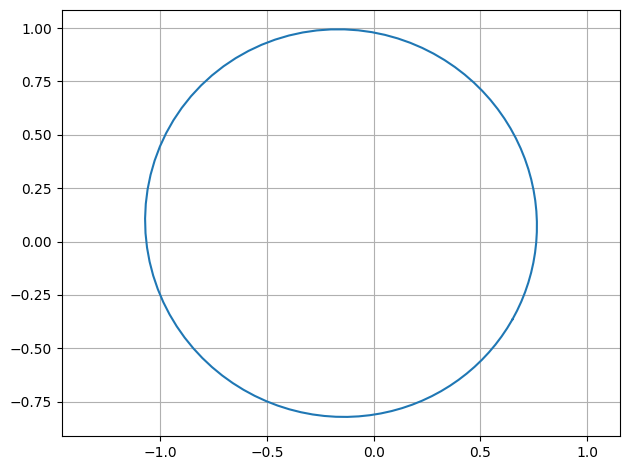

In [6]:
plt.plot(rvecs_apophis[:,0], rvecs_apophis[:,1])
plt.axis('equal')
plt.grid()
plt.tight_layout()

In [ ]:
# Earth + sun 

tabla, jd, Xj = pc.consulta_horizons(id = '399', location = "@SSB" , epochs = '2024-01-01')



targetname,datetime_jd,datetime_str,x,y,z,vx,vy,vz,lighttime,range,range_rate
---,d,---,AU,AU,AU,AU / d,AU / d,AU / d,d,AU,AU / d
str11,float64,str30,float64,float64,float64,float64,float64,float64,float64,float64,float64
Earth (399),2460310.5,A.D. 2024-Jan-01 00:00:00.0000,-0.1738192017257054,0.9663245550235138,0.0001553901854897183,-0.01723001232538228,-0.00296772134261887,6.382125383116755e-07,0.005670595209875435,0.9818331246581891,0.0001294772790419658


In [19]:
# Graph in 3d
# graph !
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rvecs_apophis[:,0], y=rvecs_apophis[:,1], z=rvecs_apophis[:,2], mode='lines', name='Cuerpo 1'))
fig.update_layout(title='Trayectorias de los cuerpos', scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
# set the aspect ratio to be equal
fig.update_layout(scene_aspectmode='data')
fig.show()